In [113]:
import fitz
import requests
import io
import pickle
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re
from bs4 import BeautifulSoup
import pandas as pd
import nltk
import random

In [14]:
doc = fitz.open("../data/test_pdf+xml/Trevisanus1567_De_alchemia_MDZ_MBS.pdf")

In [15]:
doc.page_count

24

In [16]:
p = doc.load_page(14)

In [17]:
p

page 14 of ../data/test_pdf+xml/Trevisanus1567_De_alchemia_MDZ_MBS.pdf

In [18]:
pix = p.get_pixmap()

In [19]:
pix.width

1159

In [20]:
pix.height

1740

In [21]:
np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...

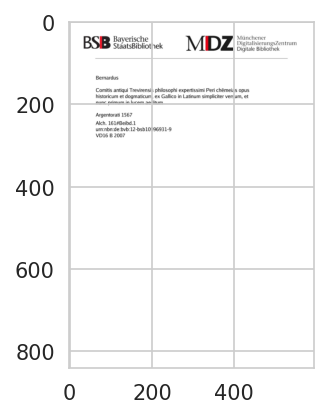

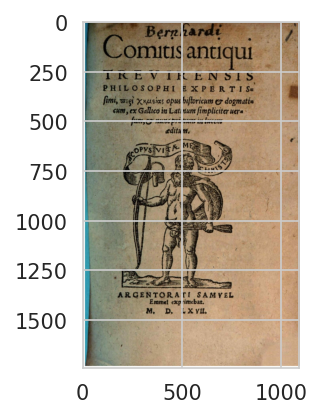

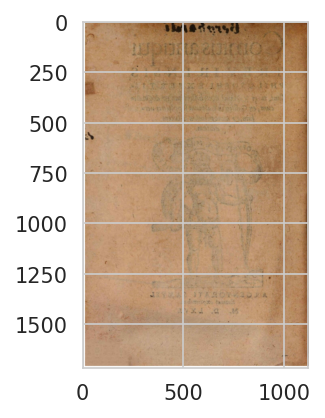

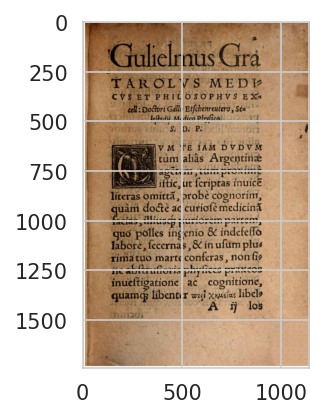

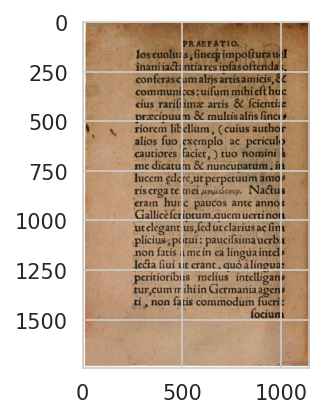

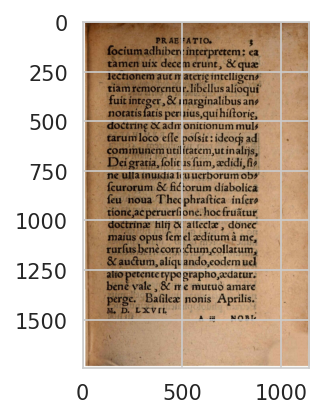

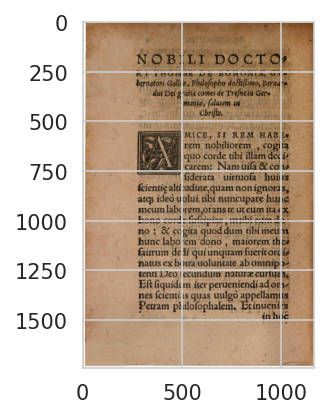

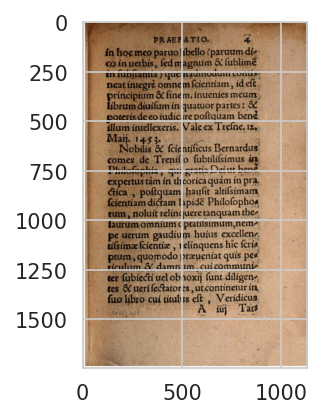

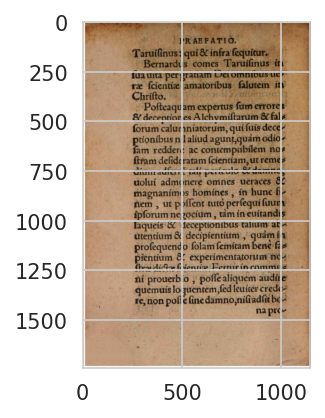

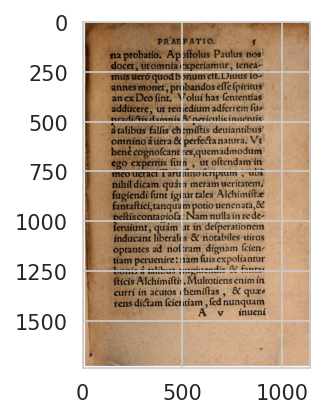

In [22]:
for p in [p for p in doc][:10]:
    pix = p.get_pixmap()
    np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...
    fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
    ax.imshow(np_array)
    plt.show()

In [23]:
print(p.get_text())

PRAEFATIO. 5
na probatio. Apostolus Paulus nos
docet, ut omnia experiamur, tenea¬
mus uerò quod bonum est. Diuus lo¬
annes monet, probandos esse spiritus
an ex Deo sint. Volui has sententias
adducere, ut remedium adferrem su¬
pradictis damnis & periculis inuentis
à talibus falsis chemistis deuiantibus
omnino à uera & perfecta natura. Vt
bene cognoscant res, quemadmodum
ego expertus sum, ut ostendam in¬
meo ueraci Taruisino scriptum, ubi
nihil dicam quàm meram ueritatem.
fugiendi sunt igitur tales Alchimistae
fantastici, tanquam potio uenenata, &
pestis contagiosa: Nam nulla in re de¬
seruiunt, quàm ut in desperationem
inducant liberales & notabiles uiros
optantes ad nostram dignam scien¬
tiam peruenire: nam suis expoliantur
bonis à talibus nugiuendis & fanta¬
sticis Alchimistis. Multotiens enim in
curri in acutos chemistas, & quae¬
rens dictam scientiam, sed nunquam
A v  inueni



In [24]:
textblocks = p.get_text_blocks() # ("blocks")
textblocks

[(367.67999267578125,
  116.88009643554688,
  890.26318359375,
  121.68009185791016,
  'PRAEFATIO. 5\n',
  0,
  0),
 (129.36000061035156,
  178.56002807617188,
  910.8695068359375,
  183.3600311279297,
  'na probatio. Apostolus Paulus nos\n',
  1,
  0),
 (133.1999969482422,
  230.88009643554688,
  903.4421997070312,
  235.6800994873047,
  'docet, ut omnia experiamur, tenea¬\n',
  2,
  0),
 (132.24000549316406,
  283.9200134277344,
  913.7489624023438,
  288.7200012207031,
  'mus uerò quod bonum est. Diuus lo¬\n',
  3,
  0),
 (129.36000061035156,
  340.5600280761719,
  903.5310668945312,
  345.3600158691406,
  'annes monet, probandos esse spiritus\n',
  4,
  0),
 (133.1999969482422,
  394.8240051269531,
  911.8640747070312,
  399.7440185546875,
  'an ex Deo sint. Volui has sententias\n',
  5,
  0),
 (133.1999969482422,
  448.5600280761719,
  912.8450317382812,
  453.3600158691406,
  'adducere, ut remedium adferrem su¬\n',
  6,
  0),
 (138.9600067138672,
  503.2799987792969,
  914.403320

In [13]:
central_textblocks = textblocks[2:-1]
len(central_textblocks)

28

In [14]:
len(textblocks)

31

In [50]:
central_textblocks = textblocks[2:-1]
avg_width = np.mean([rect[2] - rect[0] for rect in central_textblocks])
avg_left_x = np.mean([rect[0] for rect in central_textblocks])
avg_right_x = np.mean([rect[2] for rect in central_textblocks])

avg_charn = sum([len(textblock) for textblock in central_textblocks]) / len(central_textblocks)
avg_charn_density = avg_charn / avg_width

In [99]:
def check_header(textblock, avg_width, avg_left_x, header_width_proportion_max=0.8, header_left_x_ratio_min=1.2, header_uppercase_proportion_min = 0.6, header_digits_proportion_min = 0.6):
    width_ratio = (textblock[2] - textblock[0])  / avg_width # thinner than average line
    left_x_ratio = textblock[0] / avg_left_x # more right than average line
    textblock_text = textblock[4].replace("\n", "")
    uppercase_ratio = sum(1 for char in textblock_text if char.isupper()) / len(textblock_text)
    digits_ratio =  sum(1 for char in textblock_text if char.isdigit()) / len(textblock_text)
    if sum([(width_ratio < header_width_proportion_max),(left_x_ratio > header_left_x_ratio_min),(uppercase_ratio > header_uppercase_proportion_min),(digits_ratio > header_digits_proportion_min)]) >= 2: # if first
        return True
    else:
        return False
def check_footer(textblock, avg_width, avg_left_x, avg_right_x, footer_width_proportion_max=0.5, footer_left_x_ratio_min=1.2):
    width_ratio = (textblock[2] - textblock[0])  / avg_width # thinner than average line
    left_x_ratio = textblock[0] / avg_left_x # more right than average line
    right_x_ratio = textblock[2] / avg_right_x # more right than average line
    textblock_text = textblock[4].replace("\n", "")
    digits_ratio =  sum(1 for char in textblock_text if char.isdigit()) / len(textblock_text)
    if sum([(width_ratio < footer_width_proportion_max), (left_x_ratio > 1.2),  (0.9 < right_x_ratio < 1.1),(digits_ratio > 0.6)]) >= 2: # if first
        return True
    else:
        return False

def check_title(textblock, avg_charn_density, textblock_char_density_ratio_max=0.75):
    textblock_char_density = len(textblock[4]) / (textblock[2] - textblock[0])
    textblock_char_density_ratio = textblock_char_density / avg_charn_density
    if textblock_char_density_ratio < textblock_char_density_ratio_max:
        return True
    else:
        return False


In [105]:
patch_color_dict = {"title" : "green",
                    "header" : "red",
                    "footer" : "orange",
                    "margin" : "yellow",
                     "text" : "white",
}

def plot_patch(textblock_annotated, patch_color_dict):
   color = patch_color_dict[textblock_annotated[5]]
   patch = patches.Rectangle((textblock_annotated[0], textblock_annotated[1]),  # Bottom left corner
                              textblock_annotated[2] - textblock_annotated[0],  # Width
                              textblock_annotated[3] - textblock_annotated[1],  # Height
                              linewidth=0.3, edgecolor=color, facecolor='none')
   ax.add_patch(patch) # draw candidate textblocks in black

def get_page_annots(textblocks,
                    patch_color_dict=patch_color_dict,
                    header_width_proportion_max=0.8,
                    header_left_x_ratio_min=1.2,
                    header_uppercase_proportion_min=0.6,
                    header_digits_proportion_min = 0.6,
                    footer_width_proportion_max=0.5,
                    footer_left_x_ratio_min=1.2,
                    textblock_char_density_ratio_max=0.75):
    textblocks_enumerated = [[el[0], el[1], el[2], el[3], el[4], n] for n, el in enumerate(textblocks)]
    textblocks = sorted(textblocks_enumerated, key=lambda x: x[1])
    textblocks = [[el[0], el[1], el[2], el[3], el[4], el[5], n] for n, el in enumerate(textblocks)]
    central_textblocks = textblocks[2:-1]
    avg_width = np.mean([rect[2] - rect[0] for rect in central_textblocks])
    avg_left_x = np.mean([rect[0] for rect in central_textblocks])
    avg_right_x = np.mean([rect[2] for rect in central_textblocks])
    try:
        avg_charn = sum([len(textblock[4]) for textblock in central_textblocks]) / len(central_textblocks)
        avg_charn_density = avg_charn / avg_width
    except:
        avg_charn_density = 0
    textblocks_annotated = []
    for textblock in textblocks:
        annot = "text"
        if textblock[6] in [0,1]:
            if check_header(textblock, avg_width, avg_left_x, header_width_proportion_max, header_left_x_ratio_min, header_uppercase_proportion_min, header_digits_proportion_min):
                annot = "header"
        if textblock[6] == len(textblocks) -1:
            if check_footer(textblock, avg_width, avg_left_x, avg_right_x, footer_width_proportion_max, footer_left_x_ratio_min):
                annot = "footer"
        if annot != "header" and annot != "footer":
            if check_title(textblock, avg_charn_density, textblock_char_density_ratio_max):
                annot = "title"
        textblocks_annotated.append([textblock[0], textblock[1], textblock[2], textblock[3], textblock[4], textblock[5], textblock[6], annot])
    textblocks_annotated_reordered = [[el[0], el[1], el[2], el[3], el[4], el[7]] for el in sorted(textblocks_annotated, key=lambda x: x[5])]
    # marginalia to full annotations
    margin_in_progress = False
    for textblock in textblocks_annotated_reordered:
        if "[M]" in textblock[4]:  # Check for the opening marginalia tag
            textblock[4] = textblock[4].replace("[M]", "")  # Remove the tag
            margin_in_progress = True  # Marginalia started

        if margin_in_progress:  # If within a marginalia block
            textblock[5] = "margin"  # Annotate as margin

        if "[/M]" in textblock[4]:  # Check for the closing marginalia tag
            textblock[4] = textblock[4].replace("[/M]", "")  # Remove the tag
            margin_in_progress = False  # Marginalia ended
        plot_patch(textblock, patch_color_dict)
    return textblocks_annotated_reordered

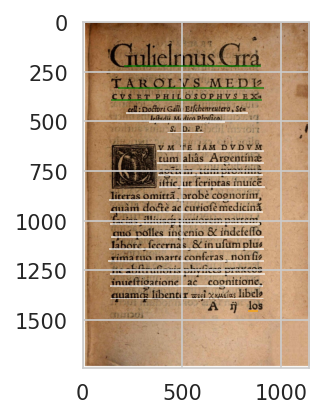

In [110]:
p = doc.load_page(3)
pix = p.get_pixmap()
np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...
fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
textblocks = p.get_text_blocks()
page_textblocks_annotated = get_page_annots(textblocks,
                    patch_color_dict=patch_color_dict,
                    header_width_proportion_max=0.8,
                    header_left_x_ratio_min=1.2,
                    header_uppercase_proportion_min=0.6,
                    header_digits_proportion_min = 0.6,
                    footer_width_proportion_max=0.5,
                    footer_left_x_ratio_min=1.2,
                    textblock_char_density_ratio_max=0.7)
ax.imshow(np_array)
plt.show()

In [111]:
page_textblocks_annotated

[[209.0399932861328,
  215.27999877929688,
  894.053955078125,
  220.0800018310547,
  'Gulielmus Gra¬\n',
  'title'],
 [175.44000244140625,
  326.9039611816406,
  910.0022583007812,
  331.823974609375,
  'TAROLVS MEDI¬\n',
  'title'],
 [143.75999450683594,
  388.5600280761719,
  899.9873657226562,
  393.3600158691406,
  'CVS ET PHILOSOPHVS EX¬\n',
  'title'],
 [215.75999450683594,
  452.3999938964844,
  825.4468994140625,
  457.1999816894531,
  'cell: Doctori Gallo Etschenreutero, Se¬\n',
  'text'],
 [331.67999267578125,
  499.6800231933594,
  710.8863525390625,
  504.4800109863281,
  'lestadij Medico Physico.\n',
  'text'],
 [425.5199890136719,
  551.2799682617188,
  603.81201171875,
  556.0800170898438,
  'S. D. P.\n',
  'text'],
 [372.9599914550781,
  644.6640014648438,
  909.0391845703125,
  649.583984375,
  'CVM TE IAM DVDVM\n',
  'text'],
 [372.0,
  703.1998901367188,
  909.5879516601562,
  707.9999389648438,
  'tum aliâs Argentinae\n',
  'text'],
 [378.7200012207031,
  765.35992

In [ ]:
# random sample of 8 pages from the doc
random.seed(0)
pages_sample = random.sample(doc, min(8, len(doc)))

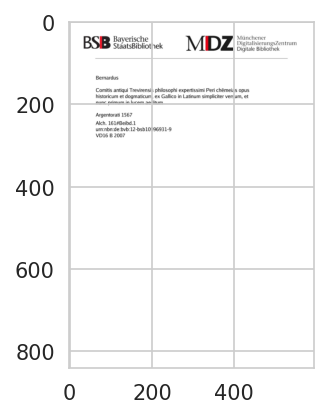

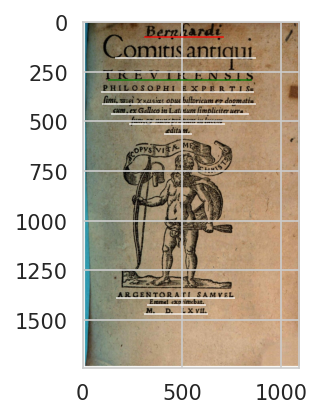

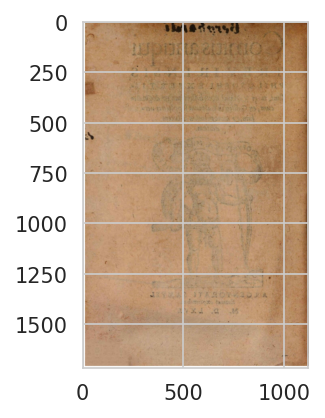

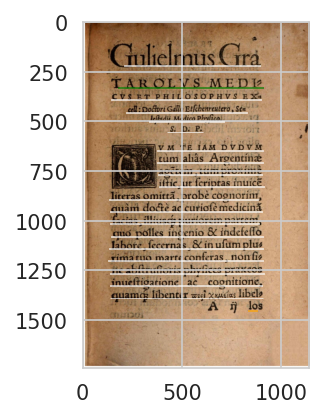

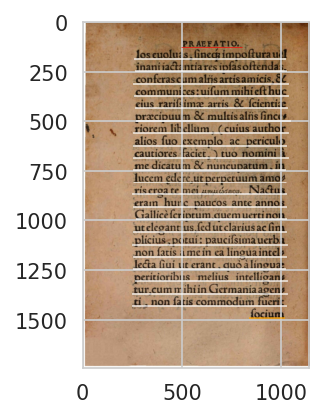

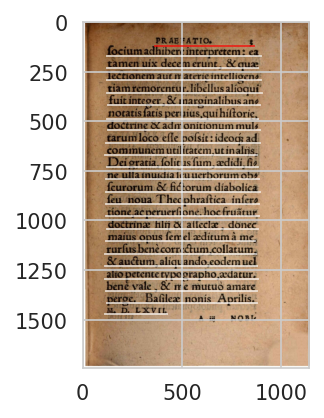

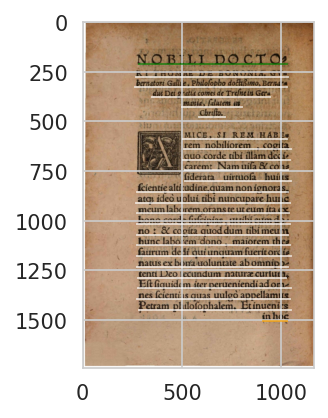

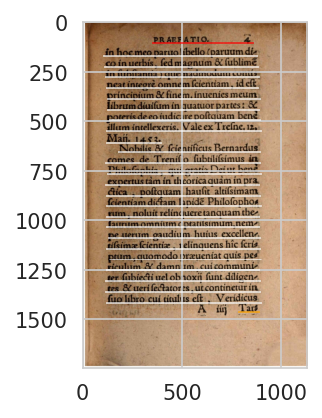

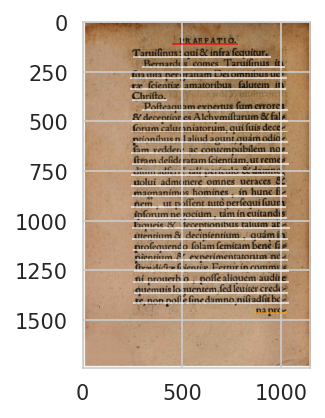

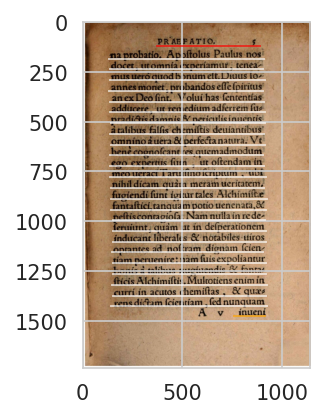

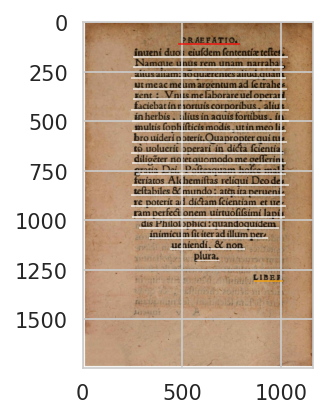

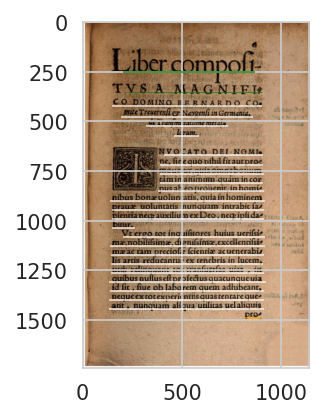

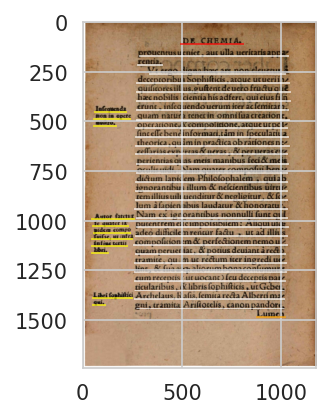

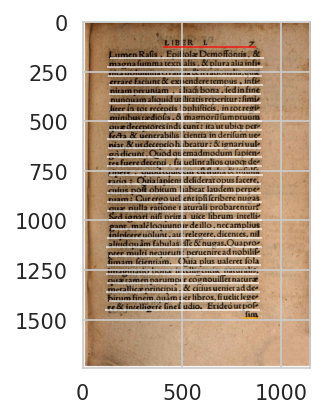

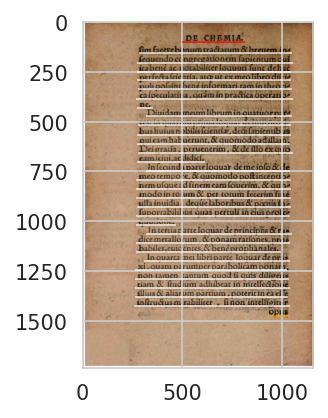

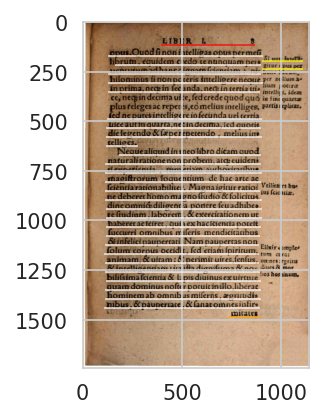

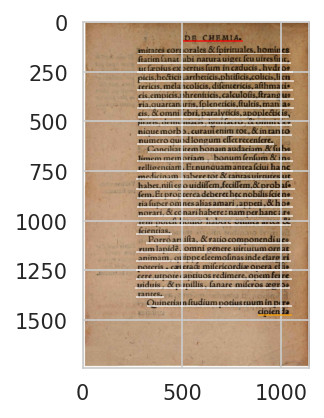

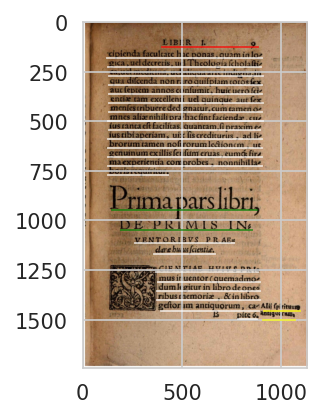

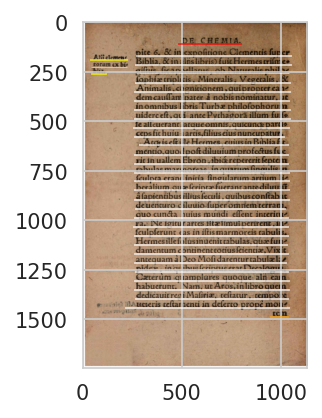

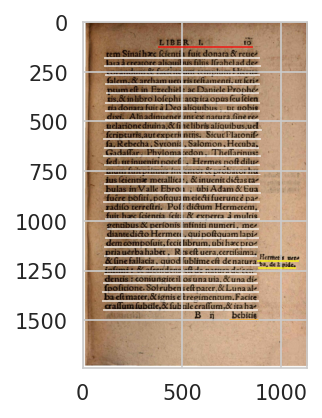

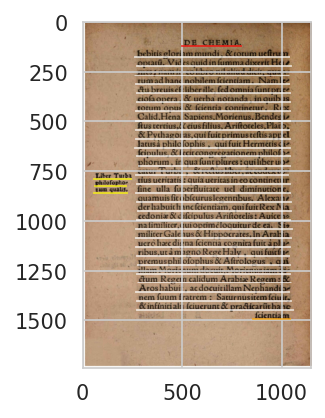

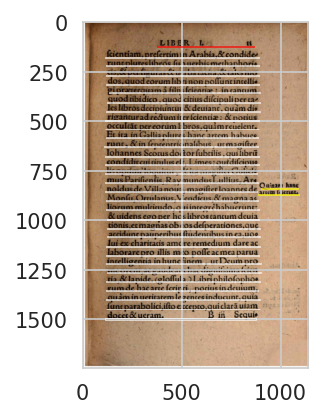

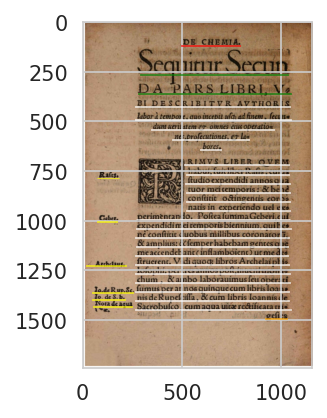

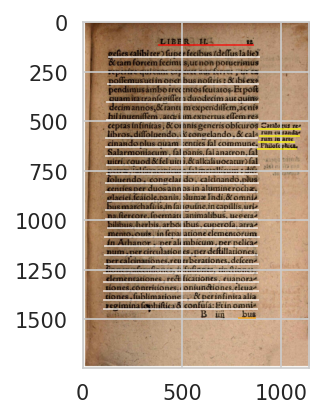

In [91]:
pages_textblocks_annotated = []
pages_sample = [p for p in doc] # random

    pix = p.get_pixmap()
    np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...
    fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
    textblocks = p.get_text_blocks()
    pages_textblocks_annotated.append(get_page_annots(textblocks))
    ax.imshow(np_array)
    plt.show()

In [33]:
pages_textblocks_annotated[0]

IndexError: list index out of range

In [102]:
pages_textblocks_annotated[-1]

[[377.5199890136719,
  112.08004760742188,
  861.5700073242188,
  116.88004302978516,
  'LIBER II. 12\n',
  'header'],
 [129.83999633789062,
  172.32003784179688,
  888.1253051757812,
  177.1200408935547,
  'gesies (alibi ter) super fecibus ([F]dessus la lie[/F])\n',
  'text'],
 [122.63999938964844,
  308.3999938964844,
  886.8301391601562,
  313.1999816894531,
  'possemus uti in operibus nostris: & ibi ex¬\n',
  'text'],
 [119.04000091552734,
  397.9200134277344,
  885.9032592773438,
  402.7200012207031,
  'quam ita transegissem duodecim aut quin¬\n',
  'text'],
 [116.63999938964844,
  489.6000671386719,
  885.3707885742188,
  494.4000549316406,
  'hil inuenissem, atque iam expertus essem re¬\n',
  'text'],
 [111.83999633789062,
  579.8400268554688,
  878.93603515625,
  584.6400756835938,
  'libros, dissoluendo, & congelando, & cal¬\n',
  'text'],
 [111.83999633789062,
  627.8400268554688,
  878.203125,
  632.6400756835938,
  'cinando plus quam centies sal commune,\n',
  'text'],
 [11

In [106]:
flattext = ""
for p_textblocks in pages_textblocks_annotated:
    for textblock in p_textblocks:
        if textblock[5] == "text":
            flattext += textblock[4]

In [107]:
print(flattext)

Comitis antiqui
TREVIRENSIS
PHILOSOPHI EXPERTIS¬
simi, περὶ χημείας opus historicum & dogmati¬
cum, ex Gallico in Latinum simpliciter uer¬
sum, & nunc primum in lucem
aeditum.
ARGENTORATI SAMVEL
Emmel exprimebat.
M. D. LXVII.
Gulielmus Gra¬
TAROLVS MEDI¬
CVS ET PHILOSOPHVS EX¬
cell: Doctori Gallo Etschenreutero, Se¬
lestadij Medico Physico.
S. D. P.
CVM TE IAM DVDVM
tum aliâs Argentinae
agentem, tùm proximè
istic, ut scriptas inuicem
literas omittam, probè cognorim
quàm doctè ac curiosè medicinam
facias, illiusque puriorem partem
quo polles ingenio & indefesso
labore, secernas, & in usum plu¬
rima tuo marte conferas, non si¬
ne abstrusioris physices praxeos
inuestigatione ac cognitione,
quamque libenter περὶ χημειασ libel¬
los euoluas, sineque impostura uel
inani iactantia res ipsas ostendas,
conferas cùm alijs artis amicis, &
communices: uisum mihi est huc
eius rarissimae artis & scientiae
praecipuum & multis alijs since¬
riorem libellum, (cuius author
alios suo exemplo ac periculo
ca